In [1]:
import cv2
import os
import numpy as np
import matplotlib.pyplot as plt
import pickle

In [3]:
affected_perimeter_feature = []

In [5]:
folder_path_affected_fruit = "Dataset/affected"

In [7]:
affected_image_names = [f for f in os.listdir(folder_path_affected_fruit)]

In [9]:
affected_image_names = sorted(affected_image_names)

In [11]:
masking_lower_bound = np.array([0, 0, 46])
masking_upper_bound = np.array([225, 255, 255])

In [13]:
for affected_image_name in affected_image_names:
    affected_image_path = os.path.join(folder_path_affected_fruit, affected_image_name)
    image = cv2.imread(affected_image_path)
    hsv_image = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
    binary_image = cv2.inRange(hsv_image, masking_lower_bound, masking_upper_bound)
    contours, hierarchy = cv2.findContours(binary_image, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
    sorted_contours = sorted(contours, key=cv2.contourArea, reverse=True)
    if len(sorted_contours) < 2:
        largest_contour = sorted_contours[0]
        affected_perimeter_feature.append(cv2.arcLength(largest_contour, True))
    else:
        largest_contour = sorted_contours[0]
        second_largest_contour = sorted_contours[1]
        sum_of_two_largest_perimeters = cv2.arcLength(largest_contour, True) + cv2.arcLength(second_largest_contour, True)
        affected_perimeter_feature.append(sum_of_two_largest_perimeters)

In [15]:
healthy_perimeter_feature = []

In [17]:
folder_path_healthy_fruit = "Dataset/healthy"

In [19]:
healthy_image_names = [f for f in os.listdir(folder_path_healthy_fruit)]

In [21]:
for healthy_image_name in healthy_image_names:
    healthy_image_path = os.path.join(folder_path_healthy_fruit, healthy_image_name)
    image = cv2.imread(healthy_image_path)
    hsv_image = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
    binary_image = cv2.inRange(hsv_image, masking_lower_bound, masking_upper_bound)
    contours, hierarchy = cv2.findContours(binary_image, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
    sorted_contours = sorted(contours, key=cv2.contourArea, reverse=True)
    if len(sorted_contours) < 2:
        largest_contour = sorted_contours[0]
        healthy_perimeter_feature.append(cv2.arcLength(largest_contour, True))
    else:
        largest_contour = sorted_contours[0]
        second_largest_contour = sorted_contours[1]
        sum_of_two_largest_perimeters = cv2.arcLength(largest_contour, True) + cv2.arcLength(second_largest_contour, True)
        healthy_perimeter_feature.append(sum_of_two_largest_perimeters)

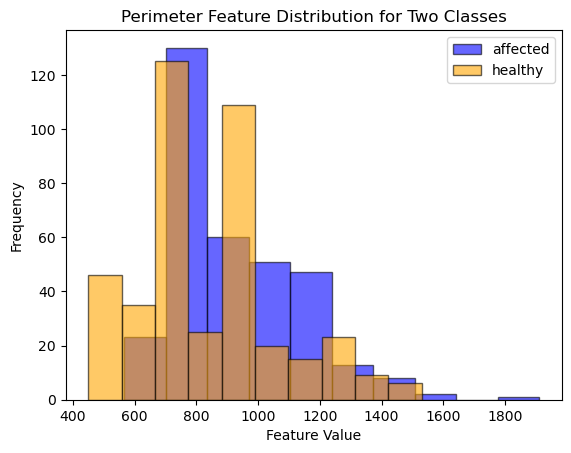

In [23]:
# Plot histograms
plt.hist(affected_perimeter_feature, bins=10, alpha=0.6, label='affected', color='blue', edgecolor='black')
plt.hist(healthy_perimeter_feature, bins=10, alpha=0.6, label='healthy', color='orange', edgecolor='black')

# Add labels and legend
plt.xlabel('Feature Value')
plt.ylabel('Frequency')
plt.title('Perimeter Feature Distribution for Two Classes')
plt.legend()

plt.show()

In [57]:
with open('affected_perimeter_feature.pkl', 'wb') as f:
    pickle.dump(affected_perimeter_feature, f)

In [59]:
with open('healthy_perimeter_feature.pkl', 'wb') as f:
    pickle.dump(healthy_perimeter_feature, f)